In [57]:
%pip install -r requirements.txt
# You dont have to have the exact versions, just have them installed and you will likely be fine
import numpy as np
import matplotlib.pyplot as plt
import re


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
### Helpers
# This function parses the system verilog palette file into a python list that lets you index into it
# EX: palette[index] returns (R, G, B) tuple
def parse_sv_palette(filepath): 
    with open(filepath, "r") as f:
        sv_text = f.read()
    entries = re.findall(r"\{4'h([0-9A-Fa-f]), 4'h([0-9A-Fa-f]), 4'h([0-9A-Fa-f])\}", sv_text)
    palette = []
    for r, g, b in entries:
        r_val = int(r, 16) * 17
        g_val = int(g, 16) * 17
        b_val = int(b, 16) * 17
        palette.append((r_val, g_val, b_val))
    return palette

# This function loads the COE file and digests it in a way similar to how you would index its addresses in SV
# EX: index = indexed_image[addr], this returns the index into the palette for the image at your calculated address
def load_coe_image_1d(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    data_line = next(i for i, line in enumerate(lines) if "memory_initialization_vector" in line)
    data = "".join(lines[data_line+1:]).replace(";", "").replace("\n", "")
    decimal_values = [int(h.strip()) for h in data.split(",") if h.strip()]
    image_data = np.array(decimal_values, dtype=np.uint8)
    return image_data

# This function is what populates your frame buffer and combines some of the logic
# You first create an empty frame buffer
# Then, going through each x and y coordinate you:
#   - calculate the address
#   - get the palette index from your indexed image at that location
#   - populate the pixel in your framebuffer with the correct color
# 
# If you have different address calculation methods, you may want to change the function call in here
def coe_to_rgb(indexed_image, palette, im_width, im_height, frame_width = 640, frame_height = 480):
    rgb_image = np.zeros((frame_height, frame_width, 3), dtype=np.uint8) # Think of this as your frame buffer that you will print at the end
    for DrawY in range(frame_height):     # These loops emulate the DrawX and DrawY creation for a frame
        for DrawX in range(frame_width):
            addr = calculate_address(DrawX, DrawY, frame_width, frame_height, im_width, im_height) # This is what you are trying to calculate
            index = indexed_image[addr] # indexes the COE image
            rgb_image[DrawY, DrawX] = palette[index] # uses the COE's index to the palette to populate an image
    return rgb_image
###

### Dynamic Address Calculation

# Using the DrawX and DrawY, you can create a dynamic address calculation for your image!
# EX: 
#   - You can add a scrolling variable that you increment in a loop so you can see your image scroll
#   - You can add a sprite select variable that you set to choose between sprites on a sprite sheet
#   - You can add a calculation that only makes you draw your image in a certain portion of the screen
#
# IMPORTANT DESIGN CONSIDERATION:
#   This is a testing script, any code you write in this block should be able to be easily translated to system verilog.
#   If you perform calculations that that would result in non synthesizable system verilog code, then this script serves
#   no purpose. The point of this notebook is to allow rapid testing of address calculations without having to regenerate
#   your bitstream, NOT to make non synthesizable code. The more simplistic you make your calculations in python, the 
#   easier they can be carried over to sv later on.
def calculate_address(DrawX, DrawY, frame_width, frame_height, im_width, im_height):
    x = (DrawX) * im_width  // frame_width
    y = (DrawY) * im_height // frame_height
    return y * im_width + x

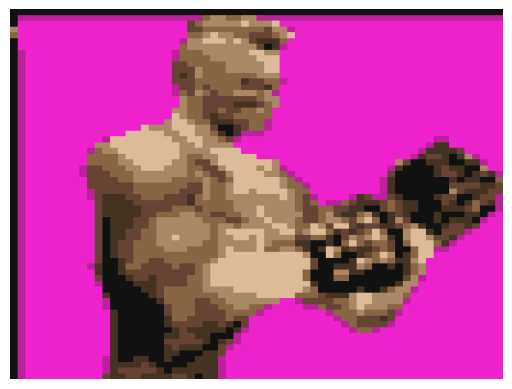

In [74]:
### Main Code

# Add COE File and Palette File to folder containing notebook
coe_image = load_coe_image_1d("./Jack/Jack.COE")        # <-- Adjust path
palette   = parse_sv_palette("./Jack/Jack_palette.sv")  # <-- Adjust path
rgb_image = coe_to_rgb(coe_image, palette, im_width=64, im_height=64)
                      # frame_width=640, frame_height=480) 

# This prints the frame buffer you just generated
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

In [1]:
import re

def find_magenta_index(palette_path):
    with open(palette_path) as f:
        text = f.read()
    entries = re.findall(
        r"\{4'h([0-9A-Fa-f]), 4'h([0-9A-Fa-f]), 4'h([0-9A-Fa-f])\}", text)
    for i, (r, g, b) in enumerate(entries):
        print(f"Index {i}: R=4'h{r} G=4'h{g} B=4'h{b}")

find_magenta_index("./Jack_new/Jack_new_palette.sv")
find_magenta_index("./Paul_new/Paul_new_palette.sv")

Index 0: R=4'hF G=4'h0 B=4'hC
Index 1: R=4'h5 G=4'h4 B=4'h1
Index 2: R=4'hC G=4'h8 B=4'h6
Index 3: R=4'h8 G=4'h4 B=4'h3
Index 4: R=4'h1 G=4'h1 B=4'h1
Index 5: R=4'hB G=4'h2 B=4'h7
Index 6: R=4'hD G=4'hB B=4'h9
Index 7: R=4'hC G=4'h0 B=4'hA
Index 8: R=4'h9 G=4'h7 B=4'h5
Index 9: R=4'h3 G=4'h2 B=4'h1
Index 10: R=4'h7 G=4'h6 B=4'h4
Index 11: R=4'h6 G=4'h4 B=4'h3
Index 12: R=4'h8 G=4'h0 B=4'h6
Index 13: R=4'h1 G=4'h1 B=4'h0
Index 14: R=4'h3 G=4'h3 B=4'h3
Index 15: R=4'hD G=4'hA B=4'h7
Index 16: R=4'hF G=4'hF B=4'hC
Index 17: R=4'hF G=4'h3 B=4'hA
Index 18: R=4'h5 G=4'h4 B=4'h2
Index 19: R=4'h3 G=4'h1 B=4'h2
Index 20: R=4'h9 G=4'h5 B=4'h4
Index 21: R=4'hA G=4'h8 B=4'h5
Index 22: R=4'hA G=4'h0 B=4'h8
Index 23: R=4'h4 G=4'h3 B=4'h2
Index 24: R=4'h6 G=4'h5 B=4'h2
Index 25: R=4'h5 G=4'h4 B=4'h4
Index 26: R=4'hB G=4'hA B=4'h7
Index 27: R=4'h8 G=4'h8 B=4'h8
Index 28: R=4'h8 G=4'h2 B=4'h5
Index 29: R=4'hE G=4'h0 B=4'hB
Index 30: R=4'h5 G=4'h3 B=4'h3
Index 31: R=4'hB G=4'h4 B=4'h7
Index 32: R=4'h8 G